Librerias

In [1]:
import os, re, random, math, pickle, lmdb, time
from pathlib import Path
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision.models.video import r2plus1d_18
import cv2

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

Configuracion

In [2]:
# ==== CONFIGURACIÓN ====
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# Rutas
LMDB_DIR = r"D:\NUEVO\Dataset_Preprocesado"
LANDMARKS_DIR = r"D:\NUEVO\Landmarks\npy_landmarks"
OUTDIR = r"C:\Users\Cesar\Desktop\Sign_Recognition\TwoStreamModel"

# Entrenamiento
NUM_FRAMES = 24
FRAME_SIZE = (128,128)
BATCH_SIZE = 32
EPOCHS = 40
WARMUP_FREEZE_EPOCHS = 3     # congelar bloques 2–3 épocas
INIT_LR_RGB = 3e-4
INIT_LR_LMK = 1e-3
WEIGHT_DECAY_RGB = 5e-4
WEIGHT_DECAY_LMK = 1e-3
LABEL_SMOOTH = 0.08
PATIENCE = 7                 # early stopping por F1 macro
DROPOUT_HEAD = 0.55
USE_DZ = True                # añadir Δ y Δ² en landmarks

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); 
if DEVICE.type == "cuda": torch.cuda.manual_seed_all(SEED)

# Sujetos (para información/documentación; el LMDB ya viene dividido)
TRAIN_SUBJ = ["H1","H10","H11","H12","H14","M2","M3","M4","M6","M7"]
VAL_SUBJ   = ["H16","H17","M13"]
TEST_SUBJ  = ["M8","M9","M15"]


Device: cuda


Datasets

In [3]:
import unicodedata, re

def _normalize_token(s: str) -> str:
    s = unicodedata.normalize('NFKD', s)
    s = ''.join(c for c in s if not unicodedata.combining(c))
    s = s.replace(' ', '_')
    s = re.sub(r'[^a-zA-Z0-9_]', '_', s)
    s = re.sub(r'_+', '_', s).strip('_')
    return s

def _normalize_id(sample_id: str) -> str:
    parts = (sample_id or '').split('|')
    if len(parts) != 4:
        # si no respeta el formato, normaliza todo por si acaso
        return _normalize_token(sample_id)
    subj, clase, muestra, tipo = parts
    return '|'.join([
        _normalize_token(subj),
        _normalize_token(clase),
        _normalize_token(muestra),
        _normalize_token(tipo)
    ])

In [4]:
def parse_id_from_filename(fname: str):
    stem = Path(fname).stem
    parts = stem.split('_')

    # Debe tener al menos: SUJETO, id, clase..., 'muestra', num, tipo...
    if len(parts) < 5:
        return None, None

    # Buscar el token 'muestra'
    try:
        m_idx = parts.index('muestra')
    except ValueError:
        # Fallback mínimo: interpreta las 3 primeras piezas, colapsa y normaliza
        sujeto  = _normalize_token('_'.join(parts[:2])) if len(parts) >= 2 else 'SUJETO_?'
        clase   = _normalize_token(parts[2]) if len(parts) > 2 else 'CLASE_?'
        muestra = 'muestra_?'  # desconocido
        tipo    = _normalize_token(parts[-1]) if parts else 'rgb'
        key_norm = _normalize_id(f"{sujeto}|{clase}|{muestra}|{tipo}")
        meta_norm = {'sujeto': sujeto, 'clase': clase, 'muestra': muestra, 'tipo': tipo}
        return meta_norm, key_norm

    # SUJETO_x siempre en las dos primeras piezas
    sujeto_raw  = '_'.join(parts[0:2])
    clase_raw   = '_'.join(parts[2:m_idx])            # puede incluir '__'
    muestra_raw = f"muestra_{parts[m_idx+1]}" if (m_idx+1) < len(parts) else 'muestra_?'
    tipo_raw    = '_'.join(parts[m_idx+2:]) if (m_idx+2) < len(parts) else 'rgb'

    # Normalizar tokens (quita tildes, colapsa '__', etc.)
    sujeto  = _normalize_token(sujeto_raw)
    clase   = _normalize_token(clase_raw)
    muestra = _normalize_token(muestra_raw)  # conserva 'muestra_1'
    tipo    = _normalize_token(tipo_raw) if tipo_raw else 'rgb'

    # Clave normalizada final
    key_norm  = _normalize_id(f"{sujeto}|{clase}|{muestra}|{tipo}")
    meta_norm = {'sujeto': sujeto, 'clase': clase, 'muestra': muestra, 'tipo': tipo}
    return meta_norm, key_norm

def temporal_resample(arr, target_T: int = 24, mode: str = "equispaced"):
    is_torch = torch.is_tensor(arr)
    if is_torch:
        T = arr.shape[0]
    elif isinstance(arr, np.ndarray):
        T = arr.shape[0]
    elif isinstance(arr, list):
        T = len(arr)
    else:
        raise TypeError(f"Tipo no soportado para temporal_resample: {type(arr)}")

    if T == target_T:
        return arr

    if mode == "pad_last" and T < target_T:
        if is_torch:
            last = arr[-1:].repeat(target_T - T, *([1] * (arr.ndim - 1)))
            return torch.cat([arr, last], dim=0)
        elif isinstance(arr, np.ndarray):
            pad = np.repeat(arr[-1:,...], repeats=(target_T - T), axis=0)
            return np.concatenate([arr, pad], axis=0)
        else:  # list
            return arr + [arr[-1]] * (target_T - T)

    # Equiespaciado (default y cuando T>target_T)
    idx = np.linspace(0, T - 1, target_T).astype(np.int64)
    if is_torch:
        return arr.index_select(0, torch.as_tensor(idx, device=arr.device))
    elif isinstance(arr, np.ndarray):
        return arr[idx]
    else:  # list
        return [arr[i] for i in idx.tolist()]

In [5]:
# ==== INDEX LANDMARKS ====
# Creamos un índice: class_name -> lista de archivos; id_canónico -> path exacto (para pairing exacto si coincide)
landmark_files = sorted([p for p in Path(LANDMARKS_DIR).glob("*.npy")])
LMK_BY_CLASS = {}
LMK_BY_ID = {}
for p in landmark_files:
    meta, key = parse_id_from_filename(p.name)
    if meta is None: 
        continue
    clase = meta['clase'].replace('_', ' ')
    LMK_BY_CLASS.setdefault(clase, []).append(str(p))
    LMK_BY_ID[key] = str(p)
print(f"Landmarks indexados: {len(LMK_BY_ID)} archivos, {len(LMK_BY_CLASS)} clases")

Landmarks indexados: 4119 archivos, 14 clases


In [6]:
# ==== DATASET RGB (LMDB) - FIX COLOR & ID ====
class LMDBVideoDataset(Dataset):
    def __init__(self, lmdb_path, num_frames=24, frame_size=(128,128)):
        self.env = lmdb.open(lmdb_path, readonly=True, lock=False, readahead=False, meminit=False)
        with self.env.begin() as txn:
            self.length = txn.stat()["entries"]
        self.num_frames = num_frames
        self.frame_size = frame_size

        classes = set()
        self.sample_meta = []
        with self.env.begin() as txn:
            for i in range(self.length):
                item = pickle.loads(txn.get(f"{i}".encode()))
                clase   = item['class']                 # ej. "A ver"
                sujeto  = item.get('sujeto', None)      # ej. "SUJETO 1"
                muestra = item.get('muestra', None)     # ej. "muestra_1"
                augment = item.get('augment', 'rgb')    # ej. "rgb" o augs en train

                classes.add(clase)

                # Construir ID compatible con nombres de .npy:
                # SUJETO 1 -> SUJETO_1   |   A ver -> A_ver
                subj_ = (sujeto or '').replace(' ', '_')
                clas_ = (clase  or '').replace(' ', '_')
                samp_ = (muestra or 'muestra_?')
                aug_  = (augment or 'rgb')
                sample_id = f"{subj_}|{clas_}|{samp_}|{aug_}"

                self.sample_meta.append({
                    'class': clase,
                    'id': sample_id
                })

        self.class_names = sorted(list(classes))
        self.class_to_idx = {c:i for i,c in enumerate(self.class_names)}

    def __len__(self): return self.length

    def __getitem__(self, idx):
        with self.env.begin() as txn:
            sample = pickle.loads(txn.get(f"{idx}".encode()))
        frames = sample['frames']
        label_name = sample['class']
        y = self.class_to_idx[label_name]

        decoded = []
        for f in frames:
            img = cv2.imdecode(np.frombuffer(f, np.uint8), cv2.IMREAD_COLOR)  # BGR
            if img is None: 
                continue
            #  FIX: convertir a RGB antes de normalizar
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            decoded.append(img)

        T = len(decoded)
        if T >= self.num_frames:
            inds = np.linspace(0, T-1, self.num_frames).astype(np.int32)
        else:
            inds = np.concatenate([np.arange(T), np.full(self.num_frames-T, T-1)]).astype(np.int32)
        sel = [decoded[i] for i in inds]

        proc = []
        for im in sel:
            im = cv2.resize(im, self.frame_size[::-1], interpolation=cv2.INTER_LINEAR)
            im = im.astype(np.float32)/255.0
            proc.append(im)

        arr = np.stack(proc, axis=0)           # (T,H,W,C) in RGB
        arr = np.transpose(arr, (3,0,1,2))     # (C,T,H,W)

        # Normalización ImageNet (RGB)
        mean = np.array([0.485,0.456,0.406]).reshape(3,1,1,1)
        std  = np.array([0.229,0.224,0.225]).reshape(3,1,1,1)
        arr = (arr - mean)/std

        x = torch.from_numpy(arr).float()
        return x, torch.tensor(y), self.sample_meta[idx]['id'], label_name

In [7]:
# ==== DATASET LANDMARKS (por path) ====
def landmarks_preprocess(x_T_P_3, use_dz=True):
    x = x_T_P_3.copy()
    T, P, D = x.shape

    # centro por media por frame
    mean_xy = x[..., :2].mean(axis=1, keepdims=True)  # (T,1,2)
    x[..., :2] = x[..., :2] - mean_xy

    # escala: norma L2 media en X/Y como proxy (interpupilar si la tuvieras)
    scale = np.maximum(np.std(x[..., :2].reshape(T, -1), axis=1, keepdims=True), 1e-6)  # (T,1)
    x[..., :2] = x[..., :2] / scale[:, None, :1]
    # estandarizar Z por secuencia
    x[..., 2] = (x[..., 2] - np.mean(x[..., 2])) / (np.std(x[..., 2]) + 1e-6)

    feats = [x.reshape(T, -1)]         # P*3
    if use_dz:
        dx = np.diff(x, n=1, axis=0, prepend=x[0:1])           # Δ
        ddx = np.diff(x, n=2, axis=0, prepend=[x[0], x[0]])    # Δ²
        feats += [dx.reshape(T,-1), ddx.reshape(T,-1)]
    out = np.concatenate(feats, axis=1)   # (T, P*D')
    return out.astype(np.float32)

class LandmarksBank:
    def __init__(self, by_id: dict, by_class: dict):
        # Asume que by_id/by_class ya están construidos con claves NORMALIZADAS.
        self.by_id = by_id
        self.by_class = by_class

    def load_by_id_or_class(self, sample_id, class_name, target_T=24, use_dz=True):
        path = None

        # --- Normalizar entrada ---
        nid    = _normalize_id(sample_id) if sample_id else None
        nclass = _normalize_token(class_name) if class_name else None

        # 1) Intento por ID normalizado
        if nid and (nid in self.by_id):
            path = self.by_id[nid]
        else:
            # 2) Intento por clase normalizada (weak pairing)
            candidates = self.by_class.get(nclass, [])
            if candidates:
                path = random.choice(candidates)

        if path is None:
            return (None, None)

        # 3) Cargar, re-muestrear y preprocesar
        try:
            seq = np.load(path)  # (T_raw, P, 3)

            # Compatibilidad: si tu temporal_resample no acepta 'mode', usa sin él.
            try:
                seq = temporal_resample(seq, target_T, mode="pad_last")
            except TypeError:
                seq = temporal_resample(seq, target_T)

            seq = landmarks_preprocess(seq, use_dz=use_dz)  # (T, C)
            return (torch.from_numpy(seq).float(), Path(path).name)

        except Exception as e:
            print(f"[LMK ERROR] {e} en {path}")
            return (None, None)

In [8]:
class TwoStreamLMDBDataset(Dataset):
    def __init__(self, lmdb_path, lmk_bank, num_frames=24, frame_size=(128,128)):
        self.rgb_ds = LMDBVideoDataset(lmdb_path, num_frames=num_frames, frame_size=frame_size)
        self.lmk_bank = lmk_bank
        self.class_to_idx = self.rgb_ds.class_to_idx
        self.class_names = self.rgb_ds.class_names
        self.in_ch = 199*3*(3 if USE_DZ else 1)  # P*D*(1+Δ+Δ²)

    def __len__(self): 
        return len(self.rgb_ds)

    def __getitem__(self, idx):
        x_rgb, y, sample_id, class_name = self.rgb_ds[idx]

        # NO desempaquetes, usa variable intermedia
        result = self.lmk_bank.load_by_id_or_class(
            sample_id, class_name, target_T=x_rgb.shape[1], use_dz=USE_DZ
        )

        if (result is None) or (result[0] is None):
            # fallback: landmarks en ceros (T, C) -> luego a (C, T)
            T = x_rgb.shape[1]
            x_lmk = torch.zeros(T, self.in_ch, dtype=torch.float32)
        else:
            x_lmk = result[0]  # (T, C)

        # (T, C) -> (C, T) para Conv1D
        x_lmk = x_lmk.transpose(0, 1)
        return x_rgb, x_lmk, y

Modelos

In [9]:
# ==== RGB BACKBONE ====
class R2Plus1D18_Backbone(nn.Module):
    def __init__(self, pretrained=True, freeze_stages=1):
        super().__init__()
        m = r2plus1d_18(weights="KINETICS400_V1" if pretrained else None)
        # separa todo menos el clasificador final
        self.stem = nn.Sequential(
            m.stem, m.layer1, m.layer2, m.layer3, m.layer4,
            nn.AdaptiveAvgPool3d((1,1,1))
        )
        in_features = m.fc.in_features  # 512
        self.out_dim = in_features
        # congelar etapas iniciales
        blocks = [m.stem, m.layer1]
        if freeze_stages >= 2: blocks.append(m.layer2)
        for b in blocks[:freeze_stages]:
            for p in b.parameters():
                p.requires_grad = False

    def forward(self, x):
        # x: (B,3,T,H,W)
        z = self.stem(x)           # (B,512,1,1,1)
        z = z.view(z.size(0), -1)  # (B,512)
        return z

In [10]:
# ==== LANDMARKS TCN ====
class LandmarksTCN(nn.Module):
    def __init__(self, in_ch, hidden=256, dropout=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, 256, kernel_size=5, padding=2), nn.ReLU(), nn.Dropout(dropout),
            nn.Conv1d(256, 256, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv1d(256, hidden, kernel_size=3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)   # -> (B, hidden, 1)
        )
        self.out_dim = hidden

    def forward(self, x):
        # x: (B, C, T)
        z = self.net(x).squeeze(-1)  # (B, hidden)
        return z

In [11]:
# ==== TWO-STREAM MID FUSION (con LayerNorm + Dropout extra) ====
class TwoStreamMidFusion(nn.Module):
    def __init__(self, num_classes, lmk_in_ch):
        super().__init__()
        # Encoders
        self.rgb = R2Plus1D18_Backbone(pretrained=True, freeze_stages=1)  # expone .out_dim (512)
        self.lmk = LandmarksTCN(in_ch=lmk_in_ch, hidden=256, dropout=0.4) # expone .out_dim (256)

        dim_rgb = self.rgb.out_dim
        dim_lmk = self.lmk.out_dim
        fusion_in = dim_rgb + dim_lmk

        # Normalización por stream para alinear escalas antes de concatenar
        self.norm_rgb = nn.LayerNorm(dim_rgb)
        self.norm_lmk = nn.LayerNorm(dim_lmk)

        # Cabeza de fusión: Dropout previo y medio
        p_drop = DROPOUT_HEAD if 'DROPOUT_HEAD' in globals() else 0.4
        self.fusion_head = nn.Sequential(
            nn.Dropout(p_drop),                 # extra dropout antes de FC
            nn.Linear(fusion_in, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p_drop),                 # extra dropout intermedio
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    @property
    def fusion_head_out(self):
        # por si quieres inspeccionar el tamaño del penúltimo bloque
        return 256

    def forward(self, x_rgb, x_lmk):
        # (B, 3, T, H, W) -> (B, dim_rgb)
        f_rgb = self.rgb(x_rgb)
        # (B, C_lmk, T) -> (B, dim_lmk)
        f_lmk = self.lmk(x_lmk)

        # normaliza cada stream y concatena
        f_rgb = self.norm_rgb(f_rgb)
        f_lmk = self.norm_lmk(f_lmk)
        z = torch.cat([f_rgb, f_lmk], dim=1)  # (B, fusion_in)

        logits = self.fusion_head(z)
        return logits

Inicialización

In [12]:
# ==== DATASETS & DATALOADERS ====
bank = LandmarksBank(LMK_BY_ID, LMK_BY_CLASS)

train_ds = TwoStreamLMDBDataset(os.path.join(LMDB_DIR, "train.lmdb"), bank,
                                num_frames=NUM_FRAMES, frame_size=FRAME_SIZE)
val_ds   = TwoStreamLMDBDataset(os.path.join(LMDB_DIR, "val.lmdb"), bank,
                                num_frames=NUM_FRAMES, frame_size=FRAME_SIZE)
test_ds  = TwoStreamLMDBDataset(os.path.join(LMDB_DIR, "test.lmdb"), bank,
                                num_frames=NUM_FRAMES, frame_size=FRAME_SIZE)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Clases:", class_names)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

# ==== MODELO ====
# canales de landmarks = P*3*(1 + Δ + Δ²) = 199*3*(3)=1791 si USE_DZ True; si no, 199*3=597
lmk_in_ch = 199 * 3 * (3 if USE_DZ else 1)

# Nota: TwoStreamMidFusion debe exponer submódulos .rgb, .lmk y .fusion_head
# y la cabeza de fusión debe llevar LayerNorm + Dropout (p. ej. p_drop=0.4)
model = TwoStreamMidFusion(num_classes=num_classes, lmk_in_ch=lmk_in_ch).to(DEVICE)

# (opcional) congela primeras capas del stream RGB aquí si haces warmup
if WARMUP_FREEZE_EPOCHS > 0 and hasattr(model, "rgb"):
    for p in model.rgb.parameters():
        p.requires_grad = False
    print(f">> RGB congelado por warmup ({WARMUP_FREEZE_EPOCHS} épocas)")

# ==== PÉRDIDA ====
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH).to(DEVICE)

# ==== OPTIMIZADOR (LR discriminativo) ====
def _freeze_bn_eval(m):
    if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d)):
        m.eval()

def rebuild_optimizer_discriminative(model,
                                     lr_backbone=1e-4,
                                     lr_head=3e-4,
                                     weight_decay=7e-4,
                                     freeze_bn_backbone=True):
    if freeze_bn_backbone and hasattr(model, "rgb"):
        model.rgb.apply(_freeze_bn_eval)

    param_groups = []
    if hasattr(model, "rgb"):
        param_groups.append({
            "params": [p for p in model.rgb.parameters() if p.requires_grad],
            "lr": lr_backbone, "weight_decay": weight_decay
        })
    if hasattr(model, "lmk"):
        param_groups.append({
            "params": [p for p in model.lmk.parameters() if p.requires_grad],
            "lr": lr_head, "weight_decay": weight_decay
        })
    if hasattr(model, "fusion_head"):
        param_groups.append({
            "params": [p for p in model.fusion_head.parameters() if p.requires_grad],
            "lr": lr_head, "weight_decay": weight_decay
        })
    return torch.optim.AdamW(param_groups)

# hiperparámetros de LR discriminativo (puedes ajustar)
WEIGHT_DECAY = WEIGHT_DECAY_LMK  # usa tu valor global, p.ej. 7e-4
LR_BACKBONE  = INIT_LR_RGB       # p.ej. 1e-4
LR_HEAD      = INIT_LR_LMK       # p.ej. 3e-4

optimizer = rebuild_optimizer_discriminative(
    model,
    lr_backbone=LR_BACKBONE,
    lr_head=LR_HEAD,
    weight_decay=WEIGHT_DECAY,
    freeze_bn_backbone=True  # mantener BN en eval durante warmup
)

# ==== SCHEDULER ====
# Importante: NO usar CosineWarmRestarts aquí.
# Activaremos ReduceLROnPlateau DESPUÉS del unfreeze dentro del loop de entrenamiento.
scheduler = None
use_plateau = False  # este flag lo activas en el loop cuando hagas el unfreeze

# ==== SCALER ====
scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE.type == "cuda"))


Clases: ['A ver', 'Aburrido', 'Cansado', 'Disgusto', 'Feliz', 'Huele mal', 'Ladron', 'Llorar', 'Molesto', 'No', 'No sé', 'Si', 'Sorpresa', 'Triste']
>> RGB congelado por warmup (3 épocas)


In [13]:
# Sanity check de 3 batches
import torch
import numpy as np

def check_batches(loader, n_batches=3):
    it = iter(loader)
    for b in range(n_batches):
        x_rgb, x_lmk, y = next(it)
        print(f"\nBatch {b+1}:")
        print(f"  RGB: {tuple(x_rgb.shape)}  dtype={x_rgb.dtype}  (esperado: (B,3,T,H,W))")
        print(f"  LMK: {tuple(x_lmk.shape)}  dtype={x_lmk.dtype}  (esperado: (B,C_lmk,T))")
        print(f"  y:   {tuple(y.shape)}      dtype={y.dtype}")

        # NaNs / infs
        for name, t in [("RGB", x_rgb), ("LMK", x_lmk)]:
            bad = torch.isnan(t).any().item() or torch.isinf(t).any().item()
            print(f"  {name} NaN/Inf: {bad}")

        # Rango RGB tras normalización (no debe estar en 0..1, sino centrado)
        print(f"  RGB mean: {x_rgb.mean().item():.3f}  std: {x_rgb.std().item():.3f}")

check_batches(train_loader, n_batches=3)



Batch 1:
  RGB: (32, 3, 24, 128, 128)  dtype=torch.float32  (esperado: (B,3,T,H,W))
  LMK: (32, 1791, 24)  dtype=torch.float32  (esperado: (B,C_lmk,T))
  y:   (32,)      dtype=torch.int64
  RGB NaN/Inf: False
  LMK NaN/Inf: False
  RGB mean: -0.110  std: 1.300

Batch 2:
  RGB: (32, 3, 24, 128, 128)  dtype=torch.float32  (esperado: (B,3,T,H,W))
  LMK: (32, 1791, 24)  dtype=torch.float32  (esperado: (B,C_lmk,T))
  y:   (32,)      dtype=torch.int64
  RGB NaN/Inf: False
  LMK NaN/Inf: False
  RGB mean: -0.088  std: 1.275

Batch 3:
  RGB: (32, 3, 24, 128, 128)  dtype=torch.float32  (esperado: (B,3,T,H,W))
  LMK: (32, 1791, 24)  dtype=torch.float32  (esperado: (B,C_lmk,T))
  y:   (32,)      dtype=torch.int64
  RGB NaN/Inf: False
  LMK NaN/Inf: False
  RGB mean: -0.135  std: 1.282


Prueba de carga de dataset

In [14]:
import re, unicodedata
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
from tqdm import tqdm

# ---------- Normalización común ----------
def _normalize_token(s: str) -> str:
    s = unicodedata.normalize('NFKD', s)
    s = ''.join(c for c in s if not unicodedata.combining(c))  # quita tildes
    s = s.replace(' ', '_')
    s = re.sub(r'[^a-zA-Z0-9_]', '_', s)
    s = re.sub(r'_+', '_', s).strip('_')
    return s

def _normalize_id(sample_id: str) -> str:
    parts = (sample_id or '').split('|')
    if len(parts) != 4:
        return _normalize_token(sample_id)
    return '|'.join(_normalize_token(p) for p in parts)

# --- util mínimo para resample (visual) ---
def temporal_resample(arr, target_T: int = 24):
    T = arr.shape[0]
    if T == target_T: 
        return arr
    idx = np.linspace(0, T-1, target_T).astype(np.int64)
    return arr[idx]

# ============= VISUALIZACIÓN =============
def show_sample(ds, idx=0, lmk_by_id=None, lmk_by_class=None, title_prefix="Split"):
    # 1) Sample
    x_rgb, x_lmk, y = ds[idx]   # x_rgb: (C,T,H,W), x_lmk: (C_lmk,T)
    class_idx = y.item()
    class_name = ds.class_names[class_idx]
    class_name_norm = _normalize_token(class_name)

    # 2) Des-normalizar RGB a [0,1]
    mean = np.array([0.485, 0.456, 0.406]).reshape(3,1,1)
    std  = np.array([0.229, 0.224, 0.225]).reshape(3,1,1)
    C, T, H, W = x_rgb.shape
    rgb_np = x_rgb.cpu().numpy()
    rgb_np = np.transpose(rgb_np, (1,2,3,0))  # (T,H,W,C)
    for t in range(T):
        rgb_np[t] = np.clip((rgb_np[t] * std.transpose(1,2,0)) + mean.transpose(1,2,0), 0.0, 1.0)

    # 3) Resolver landmarks RAW por ID normalizado; si no, por clase normalizada
    sample_id = ds.rgb_ds.sample_meta[idx]['id'] if hasattr(ds, "rgb_ds") else None
    sid_norm = _normalize_id(sample_id) if sample_id else None

    raw_lmk, lmk_filename = None, None
    if lmk_by_id and sid_norm in lmk_by_id:
        p = lmk_by_id[sid_norm]
        try:
            raw = np.load(p)      # (T_raw, P, 3)
            raw_lmk = temporal_resample(raw, T)
            lmk_filename = Path(p).name
        except Exception as e:
            print(f"[WARN] Falló carga LMK por ID: {e}")

    if raw_lmk is None and lmk_by_class:
        cand = lmk_by_class.get(class_name_norm, [])
        if len(cand) > 0:
            p = np.random.choice(cand)
            try:
                raw = np.load(p)
                raw_lmk = temporal_resample(raw, T)
                lmk_filename = Path(p).name + " (weak pairing)"
            except Exception as e:
                print(f"[WARN] Falló carga LMK por clase: {e}")

    # 4) Mostrar 4 frames
    sel_ts = [0, max(0, T//3), max(0, 2*T//3), T-1]
    fig, axes = plt.subplots(1, 4, figsize=(14, 3.8))
    for ax, t in zip(axes, sel_ts):
        ax.imshow((rgb_np[t] * 255).astype(np.uint8))
        ax.set_axis_off()
        ax.set_title(f"Frame {t+1}/{T}")
        if raw_lmk is not None:
            xs = (raw_lmk[t, :, 0] * W)
            ys = (raw_lmk[t, :, 1] * H)
            ax.scatter(xs, ys, s=8, c='lime', alpha=0.8)

    supt = f"{title_prefix} idx={idx} | clase='{class_name}' | RGB {C}x{T}x{H}x{W}"
    supt += f"\nLMK: {lmk_filename if lmk_filename else 'NO ENCONTRADOS'}"
    plt.suptitle(supt, fontsize=11)
    plt.tight_layout()
    plt.show()

    # 5) Info
    print("=== INFO SAMPLE ===")
    print(f"sample_id: {sample_id}  |  normalized: {sid_norm}")
    print(f"Clase: {class_name} (norm='{class_name_norm}') (idx={class_idx})")
    print(f"RGB tensor: {tuple(x_rgb.shape)}  | dtype={x_rgb.dtype}")
    print(f"LMK tensor (loader): {tuple(x_lmk.shape)}  | dtype={x_lmk.dtype}")
    print("Landmarks RAW archivo:", lmk_filename if lmk_filename else "NO ENCONTRADOS")

# =============== AUDITORÍA ===============
def audit_landmarks_coverage(ds, lmk_by_id, save_csv_path=None, max_rows_print=20, title="Split"):
    """
    Recorre TODO el dataset y cuenta cuántos sample_id (normalizados) tienen .npy en lmk_by_id.
    """
    have, missing = [], []
    sample_meta = ds.rgb_ds.sample_meta if hasattr(ds, "rgb_ds") else None
    if sample_meta is None:
        raise RuntimeError("El dataset no expone 'rgb_ds.sample_meta'. Usa TwoStreamLMDBDataset.")

    for i in tqdm(range(len(sample_meta)), desc=f"[Audit LMK {title}]"):
        sid_raw = sample_meta[i]['id']                 # "SUJETO_1|A_ver|muestra_1|rgb"
        sid_norm = _normalize_id(sid_raw)              # normalizado
        if sid_norm in lmk_by_id:
            have.append(sid_norm)
        else:
            missing.append(sid_raw)                    # guardamos el original para inspección

    total = len(sample_meta)
    info = {
        "total": total,
        "con_landmarks": len(have),
        "sin_landmarks": len(missing),
        "ratio_con_landmarks": len(have) / total if total else 0.0
    }

    print(f"\n=== Cobertura de Landmarks ({title}) ===")
    print(f"Total muestras      : {total}")
    print(f"Con landmarks (.npy): {len(have)}  ({info['ratio_con_landmarks']*100:.1f}%)")
    print(f"Sin landmarks       : {len(missing)}")

    if missing:
        print(f"\nEjemplos faltantes (hasta {max_rows_print}):")
        for sid in missing[:max_rows_print]:
            print("  -", sid)

    if save_csv_path:
        df = pd.DataFrame({"sample_id_raw": missing})
        df.to_csv(save_csv_path, index=False, encoding="utf-8")
        print(f"\nLista completa de faltantes guardada en: {save_csv_path}")

    return info, have, missing


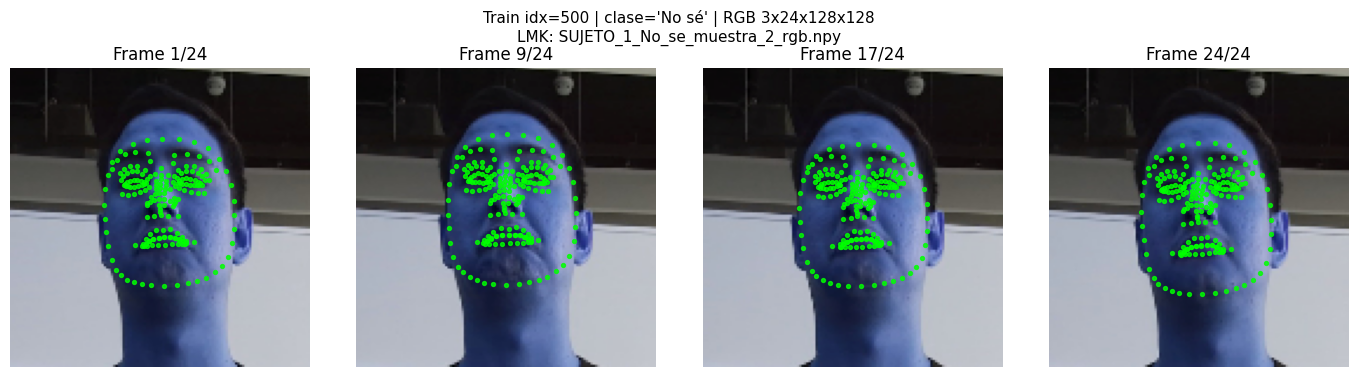

=== INFO SAMPLE ===
sample_id: SUJETO_1|No_sé|muestra_2|rgb  |  normalized: SUJETO_1|No_se|muestra_2|rgb
Clase: No sé (norm='No_se') (idx=10)
RGB tensor: (3, 24, 128, 128)  | dtype=torch.float32
LMK tensor (loader): (1791, 24)  | dtype=torch.float32
Landmarks RAW archivo: SUJETO_1_No_se_muestra_2_rgb.npy


[Audit LMK TRAIN]: 100%|██████████| 3700/3700 [00:00<00:00, 119554.76it/s]



=== Cobertura de Landmarks (TRAIN) ===
Total muestras      : 3700
Con landmarks (.npy): 3700  (100.0%)
Sin landmarks       : 0

Lista completa de faltantes guardada en: D:\NUEVO\Landmarks\missing_train.csv


[Audit LMK VAL]: 100%|██████████| 209/209 [00:00<00:00, 116974.85it/s]



=== Cobertura de Landmarks (VAL) ===
Total muestras      : 209
Con landmarks (.npy): 209  (100.0%)
Sin landmarks       : 0

Lista completa de faltantes guardada en: D:\NUEVO\Landmarks\missing_val.csv


[Audit LMK TEST]: 100%|██████████| 210/210 [00:00<00:00, 128847.84it/s]


=== Cobertura de Landmarks (TEST) ===
Total muestras      : 210
Con landmarks (.npy): 210  (100.0%)
Sin landmarks       : 0

Lista completa de faltantes guardada en: D:\NUEVO\Landmarks\missing_test.csv


In [15]:
# 1) Visualiza un ejemplo (elige índice)
show_sample(train_ds, idx=500, lmk_by_id=LMK_BY_ID, lmk_by_class=LMK_BY_CLASS, title_prefix="Train")

# 2) Audita TODO el split (train / val / test)
_ = audit_landmarks_coverage(train_ds, LMK_BY_ID, save_csv_path=r"D:\NUEVO\Landmarks\missing_train.csv", title="TRAIN")
_ = audit_landmarks_coverage(val_ds,   LMK_BY_ID, save_csv_path=r"D:\NUEVO\Landmarks\missing_val.csv",   title="VAL")
_ = audit_landmarks_coverage(test_ds,  LMK_BY_ID, save_csv_path=r"D:\NUEVO\Landmarks\missing_test.csv",  title="TEST")


Entrenamiento

In [16]:
# ==== MÉTRICAS ====
def metrics_from_logits(logits, y_true):
    y_pred = logits.argmax(1)
    acc = (y_pred == y_true).float().mean().item()
    return acc, y_pred

def f1_macro(y_true, y_pred, num_classes):
    # simple wrapper (sklearn para estabilidad)
    from sklearn.metrics import f1_score
    y_true = y_true.detach().cpu().numpy()
    y_pred = y_pred.detach().cpu().numpy()
    return f1_score(y_true, y_pred, average='macro')

# ==== HELPERS: LR discriminativo y BN freeze ====
import torch.nn as nn
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score

def _freeze_bn_eval(module):
    if isinstance(module, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d)):
        module.eval()

def rebuild_optimizer_discriminative(model,
                                     lr_backbone=1e-4,
                                     lr_head=3e-4,
                                     weight_decay=7e-4,
                                     freeze_bn_backbone=True):
    if freeze_bn_backbone and hasattr(model, "rgb"):
        model.rgb.apply(_freeze_bn_eval)

    pg = []
    if hasattr(model, "rgb"):
        pg.append({"params": [p for p in model.rgb.parameters() if p.requires_grad],
                   "lr": lr_backbone, "weight_decay": weight_decay})
    if hasattr(model, "lmk"):
        pg.append({"params": [p for p in model.lmk.parameters() if p.requires_grad],
                   "lr": lr_head, "weight_decay": weight_decay})
    if hasattr(model, "fusion_head"):
        pg.append({"params": [p for p in model.fusion_head.parameters() if p.requires_grad],
                   "lr": lr_head, "weight_decay": weight_decay})

    return torch.optim.AdamW(pg)

# ==== LOOP ====
history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[],
           "train_f1":[],"val_f1":[], "lr_backbone":[], "lr_head":[],
           "best_epoch":None}

best_val_f1, no_improve = 0.0, 0
save_path = os.path.join(OUTDIR, "best_twostream_midfusion.pth")

# --- Optimizer inicial (antes del unfreeze) ---
WEIGHT_DECAY = 7e-4
LR_BACKBONE  = 1e-4
LR_HEAD      = 3e-4
optimizer = rebuild_optimizer_discriminative(model,
                                             lr_backbone=LR_BACKBONE,
                                             lr_head=LR_HEAD,
                                             weight_decay=WEIGHT_DECAY,
                                             freeze_bn_backbone=True)
# Scheduler se activará luego del unfreeze (ReduceLROnPlateau)
scheduler = None
use_plateau = False

for epoch in range(1, EPOCHS+1):
    t0 = time.time()
    model.train()

    # --- Unfreeze al terminar warmup: reconstruir optimizer y activar Plateau ---
    if epoch == WARMUP_FREEZE_EPOCHS + 1:
        # Unfreeze total del stream RGB
        if hasattr(model, "rgb"):
            for p in model.rgb.parameters():
                p.requires_grad = True
        print(">> UNFREEZE total del stream RGB")

        # Reconstruir optimizer con LR discriminativo (y BN congelado 2–3 épocas)
        optimizer = rebuild_optimizer_discriminative(model,
                                                     lr_backbone=LR_BACKBONE,
                                                     lr_head=LR_HEAD,
                                                     weight_decay=WEIGHT_DECAY,
                                                     freeze_bn_backbone=True)
        from torch.optim.lr_scheduler import ReduceLROnPlateau
        scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5,
                                      patience=2, min_lr=1e-6)
        use_plateau = True

    # -------- TRAIN --------
    train_loss, train_accs, train_preds, train_trues = 0.0, [], [], []
    for (x_rgb, x_lmk, y) in tqdm(train_loader, desc=f"[Train {epoch}/{EPOCHS}]"):
        x_rgb = x_rgb.to(DEVICE); x_lmk = x_lmk.to(DEVICE); y = y.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type='cuda', enabled=(DEVICE.type=='cuda')):
            logits = model(x_rgb, x_lmk)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer); scaler.update()

        train_loss += loss.item() * x_rgb.size(0)
        acc, y_pred = metrics_from_logits(logits, y)
        train_accs.append(acc)
        train_preds.append(y_pred)
        train_trues.append(y)

    train_loss /= len(train_ds)
    train_acc = float(np.mean(train_accs))
    train_f1 = f1_macro(torch.cat(train_trues), torch.cat(train_preds), num_classes)

    # -------- VALID --------
    model.eval()
    val_loss, val_accs, val_preds, val_trues = 0.0, [], [], []
    with torch.no_grad():
        for (x_rgb, x_lmk, y) in tqdm(val_loader, desc=f"[Val {epoch}/{EPOCHS}]"):
            x_rgb = x_rgb.to(DEVICE); x_lmk = x_lmk.to(DEVICE); y = y.to(DEVICE)
            with torch.autocast(device_type='cuda', enabled=(DEVICE.type=='cuda')):
                logits = model(x_rgb, x_lmk)
                loss = criterion(logits, y)
            val_loss += loss.item() * x_rgb.size(0)
            acc, y_pred = metrics_from_logits(logits, y)
            val_accs.append(acc)
            val_preds.append(y_pred)
            val_trues.append(y)

    val_loss /= len(val_ds)
    val_acc = float(np.mean(val_accs))
    val_trues_cat = torch.cat(val_trues)
    val_preds_cat = torch.cat(val_preds)
    val_f1 = f1_macro(val_trues_cat, val_preds_cat, num_classes)

    # ---- F1 por clase (log + CSV por época) ----
    y_true_np = val_trues_cat.cpu().numpy()
    y_pred_np = val_preds_cat.cpu().numpy()
    f1_per_class = f1_score(y_true_np, y_pred_np, average=None, labels=list(range(num_classes)))
    df_f1 = pd.DataFrame({
        "class_idx": list(range(num_classes)),
        "class_name": [class_names[i] for i in range(num_classes)],
        "f1": f1_per_class
    }).sort_values("f1", ascending=False)

    print("\nTop-5 clases por F1 (val):")
    print(df_f1.head(5).to_string(index=False))
    print("\nBottom-5 clases por F1 (val):")
    print(df_f1.tail(5).to_string(index=False))

    Path(OUTDIR).mkdir(parents=True, exist_ok=True)
    df_f1.sort_values("class_idx").to_csv(Path(OUTDIR)/f"val_f1_per_class_epoch_{epoch:02d}.csv",
                                          index=False, encoding="utf-8")

    # ---- Scheduler ----
    if use_plateau and (scheduler is not None):
        scheduler.step(val_loss)  # ReduceLROnPlateau usa la métrica (val_loss)
    # Si tuvieras otro scheduler antes del unfreeze, NO lo uses en paralelo.

    # ---- Log de LR (backbone/head) ----
    lr_backbone_log, lr_head_log = None, None
    if len(optimizer.param_groups) >= 2:
        lr_backbone_log = optimizer.param_groups[0]['lr']
        lr_head_log     = optimizer.param_groups[1]['lr']
    else:
        lr_backbone_log = optimizer.param_groups[0]['lr']
        lr_head_log     = optimizer.param_groups[0]['lr']

    # ---- Guardar historia ----
    history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc);   history["val_acc"].append(val_acc)
    history["train_f1"].append(train_f1);     history["val_f1"].append(val_f1)
    history["lr_backbone"].append(lr_backbone_log)
    history["lr_head"].append(lr_head_log)

    print(f"\nEpoch {epoch:02d}/{EPOCHS} - {time.time()-t0:.1f}s")
    print(f"Train: loss={train_loss:.4f} | acc={train_acc:.4f} | f1={train_f1:.4f}")
    print(f"Val:   loss={val_loss:.4f} | acc={val_acc:.4f} | f1={val_f1:.4f} | "
          f"lr_bb={lr_backbone_log:.6f} | lr_head={lr_head_log:.6f}")

    # ---- Selección por F1 ----
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        no_improve = 0
        history["best_epoch"] = epoch
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "class_to_idx": train_ds.class_to_idx,
            "val_f1": val_f1,
            "val_acc": val_acc,
        }, save_path)
        print(f"✓ Mejor modelo guardado (Val F1: {val_f1:.4f}) → {save_path}")
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f" Early stopping (sin mejora {PATIENCE} épocas). "
                  f"Mejor F1={best_val_f1:.4f} @epoch {history['best_epoch']}")
            break


[Val 1/40]: 100%|██████████| 7/7 [00:17<00:00,  2.44s/it]



Top-5 clases por F1 (val):
 class_idx class_name       f1
         9         No 0.736842
         4      Feliz 0.727273
        12   Sorpresa 0.571429
        11         Si 0.434783
         7     Llorar 0.350877

Bottom-5 clases por F1 (val):
 class_idx class_name       f1
         3   Disgusto 0.090909
         0      A ver 0.000000
         1   Aburrido 0.000000
        10      No sé 0.000000
        13     Triste 0.000000

Epoch 01/40 - 394.7s
Train: loss=2.5651 | acc=0.1538 | f1=0.1507
Val:   loss=2.4108 | acc=0.3159 | f1=0.2807 | lr_bb=0.000100 | lr_head=0.000300
✓ Mejor modelo guardado (Val F1: 0.2807) → C:\Users\Cesar\Desktop\Sign_Recognition\TwoStreamModel\best_twostream_midfusion.pth


[Val 2/40]: 100%|██████████| 7/7 [00:15<00:00,  2.19s/it]



Top-5 clases por F1 (val):
 class_idx class_name       f1
         9         No 0.800000
         4      Feliz 0.500000
        12   Sorpresa 0.421053
         7     Llorar 0.382353
        11         Si 0.380952

Bottom-5 clases por F1 (val):
 class_idx class_name     f1
        13     Triste 0.0625
         3   Disgusto 0.0000
         1   Aburrido 0.0000
         0      A ver 0.0000
        10      No sé 0.0000

Epoch 02/40 - 367.8s
Train: loss=2.2001 | acc=0.3101 | f1=0.2911
Val:   loss=2.3563 | acc=0.2495 | f1=0.2303 | lr_bb=0.000100 | lr_head=0.000300


[Val 3/40]: 100%|██████████| 7/7 [00:15<00:00,  2.19s/it]


...


Top-5 clases por F1 (val):
 class_idx class_name       f1
         4      Feliz 0.965517
         9         No 0.909091
        11         Si 0.909091
         8    Molesto 0.838710
         7     Llorar 0.823529

Bottom-5 clases por F1 (val):
 class_idx class_name       f1
        10      No sé 0.600000
         0      A ver 0.434783
         6     Ladron 0.421053
         1   Aburrido 0.370370
         3   Disgusto 0.355556

Epoch 23/40 - 484.3s
Train: loss=0.4934 | acc=1.0000 | f1=1.0000
Val:   loss=1.5495 | acc=0.6683 | f1=0.6653 | lr_bb=0.000003 | lr_head=0.000009


[Val 24/40]: 100%|██████████| 7/7 [00:15<00:00,  2.19s/it]



Top-5 clases por F1 (val):
 class_idx class_name       f1
         9         No 0.967742
         4      Feliz 0.965517
        11         Si 0.937500
         7     Llorar 0.928571
         8    Molesto 0.857143

Bottom-5 clases por F1 (val):
 class_idx class_name       f1
        13     Triste 0.583333
         0      A ver 0.538462
         6     Ladron 0.421053
         3   Disgusto 0.390244
         1   Aburrido 0.375000

Epoch 24/40 - 484.2s
Train: loss=0.4943 | acc=1.0000 | f1=1.0000
Val:   loss=1.5003 | acc=0.6956 | f1=0.7005 | lr_bb=0.000002 | lr_head=0.000005


[Val 25/40]: 100%|██████████| 7/7 [00:15<00:00,  2.19s/it]


Top-5 clases por F1 (val):
 class_idx class_name       f1
         7     Llorar 0.967742
         4      Feliz 0.965517
        11         Si 0.937500
         8    Molesto 0.909091
         9         No 0.882353

Bottom-5 clases por F1 (val):
 class_idx class_name       f1
        10      No sé 0.645161
         0      A ver 0.560000
         1   Aburrido 0.428571
         6     Ladron 0.421053
         3   Disgusto 0.380952

Epoch 25/40 - 483.6s
Train: loss=0.4943 | acc=1.0000 | f1=1.0000
Val:   loss=1.4817 | acc=0.7214 | f1=0.7180 | lr_bb=0.000002 | lr_head=0.000005
 Early stopping (sin mejora 7 épocas). Mejor F1=0.7292 @epoch 18


Evaluación en Test

[Test]: 100%|██████████| 7/7 [00:22<00:00,  3.17s/it]



========== RESULTADOS EN TEST ==========
Accuracy:  0.5524
F1_macro:  0.5812
F1_micro:  0.5524

REPORTE DE CLASIFICACIÓN (TEST)

              precision    recall  f1-score   support

       A ver     0.2353    0.2667    0.2500        15
    Aburrido     0.3043    0.4375    0.3590        16
     Cansado     0.8000    0.7500    0.7742        16
    Disgusto     0.1000    0.2143    0.1364        14
       Feliz     0.8462    0.7333    0.7857        15
   Huele mal     0.3158    0.4000    0.3529        15
      Ladron     1.0000    0.2667    0.4211        15
      Llorar     0.9000    0.6000    0.7200        15
     Molesto     1.0000    0.8571    0.9231        14
          No     0.6154    0.5333    0.5714        15
       No sé     0.4118    0.4667    0.4375        15
          Si     1.0000    0.7333    0.8462        15
    Sorpresa     0.8182    0.6000    0.6923        15
      Triste     0.8667    0.8667    0.8667        15

    accuracy                         0.5524       210
   m

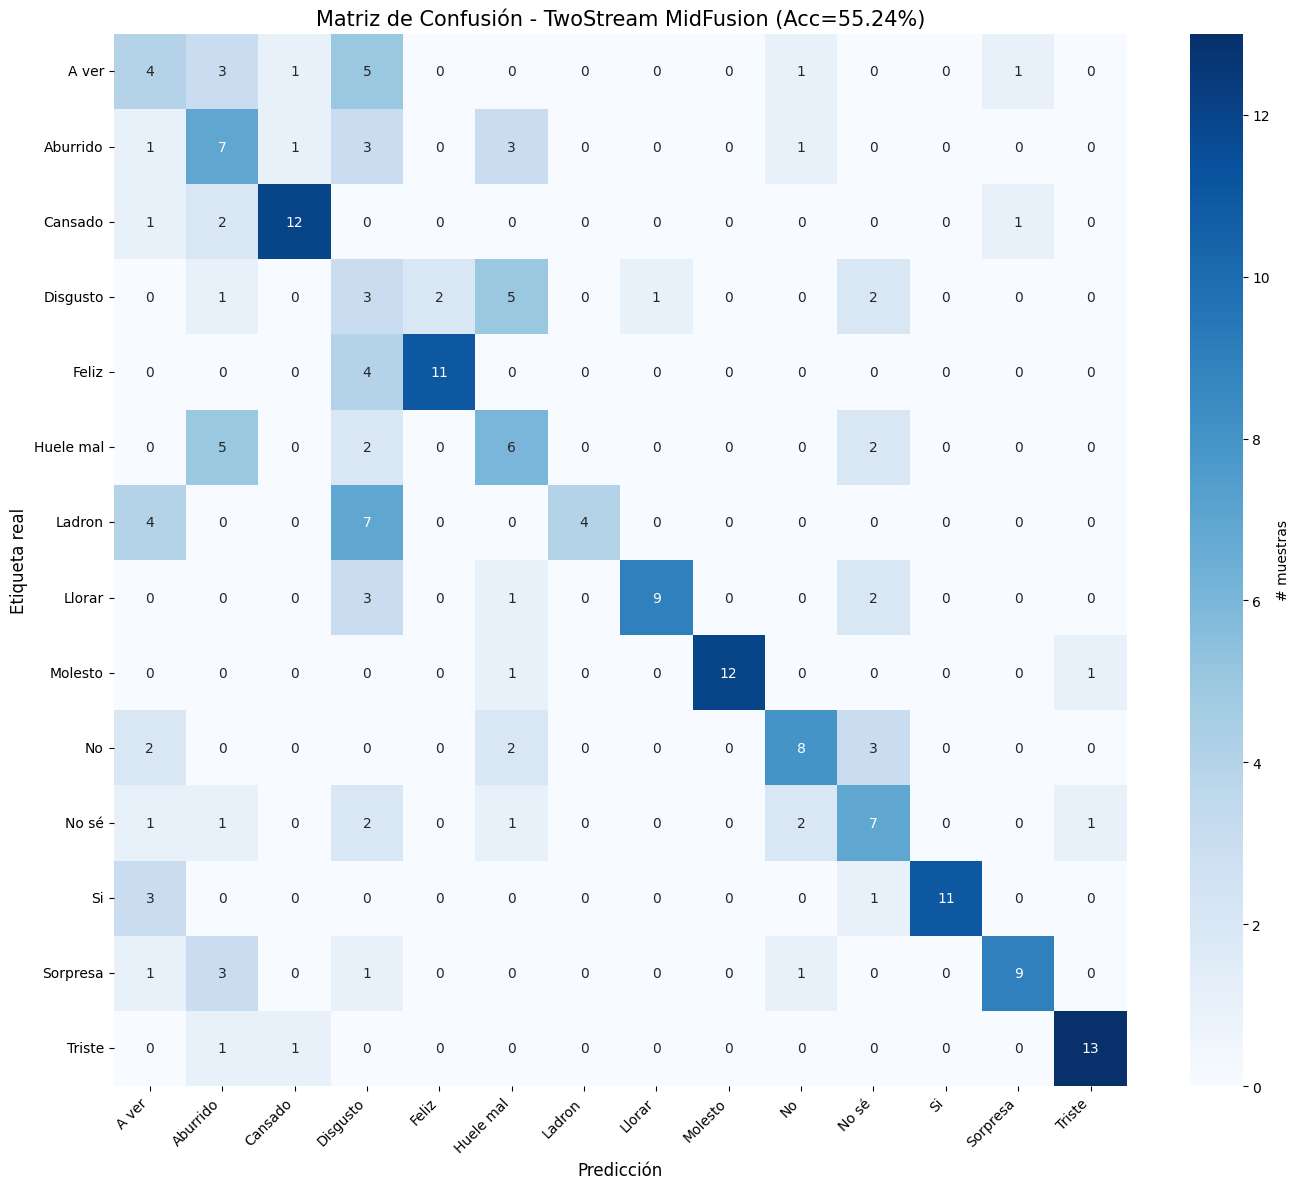

In [18]:
# ==== EVALUACIÓN TEST (robusta) ====
import os, torch
import numpy as np
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Asegura OUTDIR y SAVE_PATH
if 'OUTDIR' not in globals():
    OUTDIR = r"C:\Users\Cesar\Desktop\Sign_Recognition\TwoStreamModel"  # ajusta si usas otra
SAVE_PATH = os.path.join(OUTDIR, "best_twostream_midfusion.pth")  # misma ruta usada al guardar

assert os.path.exists(SAVE_PATH), f"No se encontró el checkpoint: {SAVE_PATH}"

# 2) Carga checkpoint
ckpt = torch.load(SAVE_PATH, map_location=DEVICE)

# 3) Reconstruye el modelo si no existe (o si se reinició el kernel)
if 'model' not in globals():
    # Si usas USE_DZ y 199 puntos:
    lmk_in_ch = 199*3*(3 if 'USE_DZ' in globals() and USE_DZ else 1)
    num_classes_ckpt = len(ckpt.get('class_to_idx', {})) if 'class_to_idx' in ckpt else None
    num_classes_eval  = num_classes_ckpt if num_classes_ckpt is not None else (len(test_ds.class_names) if 'test_ds' in globals() else 14)
    model = TwoStreamMidFusion(num_classes=num_classes_eval, lmk_in_ch=lmk_in_ch).to(DEVICE)

# 4) Carga pesos y eval mode
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

# 5) Nombres de clases coherentes con el mapeo del entrenamiento
if 'class_names' not in globals():
    if 'class_to_idx' in ckpt:
        idx_to_class = {v:k for k,v in ckpt['class_to_idx'].items()}
        class_names = [idx_to_class[i] for i in range(len(idx_to_class))]
    else:
        class_names = test_ds.class_names  # fallback

# 6) Inferencia en test
all_logits, all_y = [], []
with torch.no_grad():
    for (x_rgb, x_lmk, y) in tqdm(test_loader, desc="[Test]"):
        x_rgb = x_rgb.to(DEVICE); x_lmk = x_lmk.to(DEVICE); y = y.to(DEVICE)
        logits = model(x_rgb, x_lmk)
        all_logits.append(logits.cpu()); all_y.append(y.cpu())

all_logits = torch.cat(all_logits); all_y = torch.cat(all_y)
y_pred = all_logits.argmax(1).numpy()
y_true = all_y.numpy()

# 7) Métricas globales
acc = (y_pred == y_true).mean()
f1_macro_val = f1_score(y_true, y_pred, average="macro")
f1_micro_val = f1_score(y_true, y_pred, average="micro")

print("\n========== RESULTADOS EN TEST ==========")
print(f"Accuracy:  {acc:.4f}")
print(f"F1_macro:  {f1_macro_val:.4f}")
print(f"F1_micro:  {f1_micro_val:.4f}")

# 8) Reporte por clase
report = classification_report(y_true, y_pred, target_names=class_names, digits=4, zero_division=0)
print("\nREPORTE DE CLASIFICACIÓN (TEST)\n")
print(report)

Path(OUTDIR).mkdir(parents=True, exist_ok=True)
with open(os.path.join(OUTDIR, "twostream_classification_report_test.txt"), "w", encoding="utf-8") as f:
    f.write(report)

# 9) Matriz de confusión
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14,12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label':'# muestras'})
plt.xlabel("Predicción", fontsize=12); plt.ylabel("Etiqueta real", fontsize=12)
plt.title(f"Matriz de Confusión - TwoStream MidFusion (Acc={acc:.2%})", fontsize=15)
plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "twostream_confusion_matrix_test.png"), dpi=300)
plt.show()
